# Figure 1 — Classification of unproductive splice junctions

LeafCutter2 assigns each splice junction to one of three classes using only
start- and stop-codon annotation: **productive**, **unproductive** (the junction
introduces a premature termination codon), or **near-UTR**, where the reading
frame in use cannot be resolved and no call is made.

| Panel | What it shows |
|---|---|
| **c** | Junction tracks at *SRSF4*, coloured by class |
| **d** | Class composition by junction usage quartile |
| **e** | GENCODE v46 transcript-type composition of each class |
| **g** | log2 fold change of junction usage under four perturbations that stabilise NMD substrates |
| **h** | Three rules predicting how efficiently a premature stop triggers NMD |

Of 967,006 junctions, 33% are called unproductive, 29% productive and 38%
near-UTR. The split tracks how often a junction is used: 55% of the most-used
quartile is productive, against 17% of the least-used.

In [1]:
import os
from matplotlib import pyplot as plt

import Figure1_helpers as H
import Figure1_plot_helpers as P

plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

PLOTS_DIR = 'plots'
os.makedirs(PLOTS_DIR, exist_ok=True)
print('reading pipeline output from', H.SOURCE)

reading pipeline output from /project2/yangili1/yangili/chRNA/nmd_splicing_rules/add_on_script


In [2]:
# Fast path: reload what run_all() pickled.
data = H.load_plot_data('figure_data')

fig1c_tracks = data['fig1c_tracks']
fig1d_data   = data['fig1d_data']
fig1e_data   = data['fig1e_data']
fig1g_data   = data['fig1g_data']
fig1h_data   = data['fig1h_data']
fig1i_data   = data['fig1i_data']

In [3]:
# Full rebuild. Reads the 50 MB classification table and the 43 MB log2FC
# cache, so it takes a few minutes. Run once, then use the cell above.

# Panel i is prepared first by Figure1_fig1i.ipynb (R kernel), which reads
# the Geuvadis tables and writes fig1i_*.tsv into figure_data/. Then:
# data = H.run_all('figure_data')

### Fig. 1c — SRSF4 browser tracks

The published panel is an IGV screenshot, so there is no plotting code to
recover. What is recovered is the data behind the junction track: the BED12
records, joined to the LeafCutter2 class and GENCODE annotation of each junction,
restricted to *SRSF4*. These are written to `source_data/` rather than plotted.

In [4]:
for q, df in fig1c_tracks.items():
    counts = df.leafcutter2_category.value_counts().to_dict()
    print(f'{q:>4}: {len(df):3d} SRSF4 junctions  {counts}')

 ALL:  97 SRSF4 junctions  {'unproductive': 62, 'productive': 26, 'utr': 9}
  Q1:  14 SRSF4 junctions  {'unproductive': 10, 'utr': 3, 'productive': 1}
  Q2:  16 SRSF4 junctions  {'unproductive': 11, 'productive': 3, 'utr': 2}
  Q3:  18 SRSF4 junctions  {'unproductive': 11, 'productive': 4, 'utr': 3}
  Q4:  24 SRSF4 junctions  {'unproductive': 13, 'productive': 10, 'utr': 1}


### Fig. 1d — classification by usage quartile

Junctions split into quartiles by usage, then the share of each LeafCutter2
class. Frequently used junctions are mostly productive; rarely used ones are
mostly not.

category  productive  unproductive   utr
quartile                                
ALL             28.8          32.7  38.6
Q1              16.9          38.6  44.5
Q2              19.0          37.7  43.3
Q3              23.7          35.2  41.1
Q4              55.4          19.2  25.3


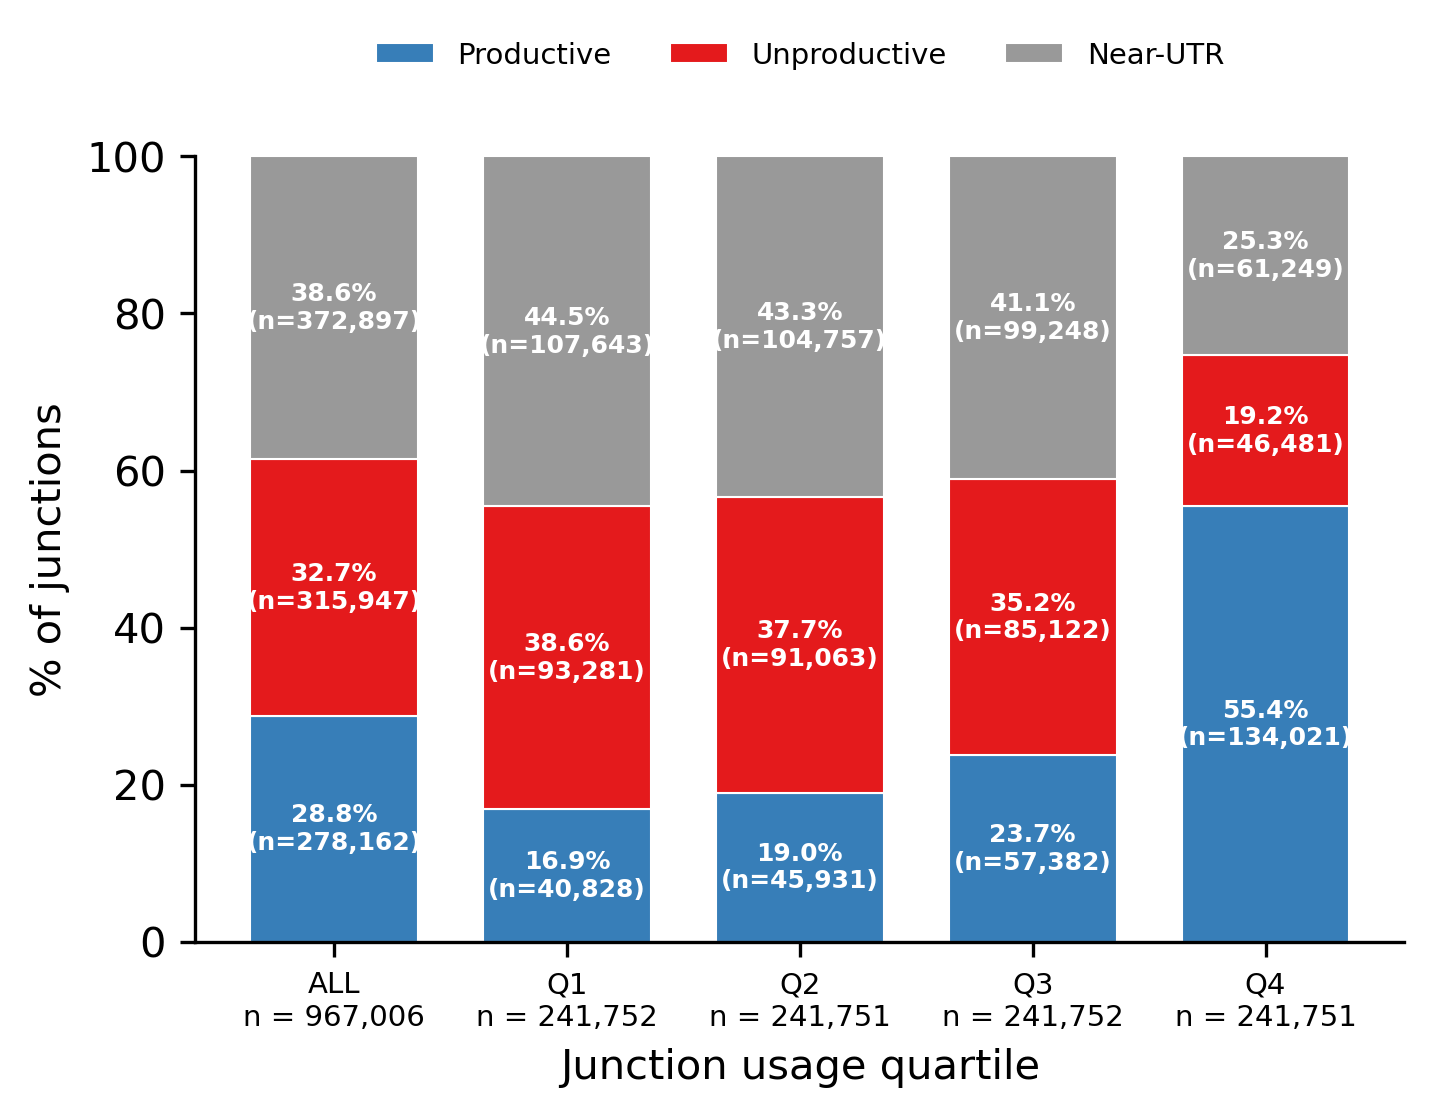

In [5]:
P.plot_fig1d(fig1d_data)
P.save_panel('fig1d', PLOTS_DIR)

pct = fig1d_data.pivot(index='quartile', columns='category', values='pct_junctions').round(1)
print(pct.to_string())

### Fig. 1e — GENCODE composition of each class

What GENCODE v46 calls the junctions LeafCutter2 assigns to each class,
restricted to the junctions GENCODE annotates at all. Of unproductive junctions
that are annotated, 54% sit in `nonsense_mediated_decay` transcripts, 34% in
`protein_coding_CDS_not_defined` and 7% in `retained_intron`; of productive
ones, 95% sit in `protein_coding` transcripts.

The restriction matters: `not_in_gencode` accounts for 94% of the unproductive
class, and including it would swamp the comparison. That fraction is itself the
point — most unproductive junctions are absent from GENCODE entirely.

                               gencode_annotation  pct_of_class
category_label                                                 
Near-UTR       20                  protein_coding          64.6
               21  protein_coding_CDS_not_defined          16.8
               19         nonsense_mediated_decay          13.8
Productive     4                   protein_coding          95.3
               3          nonsense_mediated_decay           2.3
               5   protein_coding_CDS_not_defined           1.6
Unproductive   12         nonsense_mediated_decay          53.7
               14  protein_coding_CDS_not_defined          33.5
               16                 retained_intron           7.2


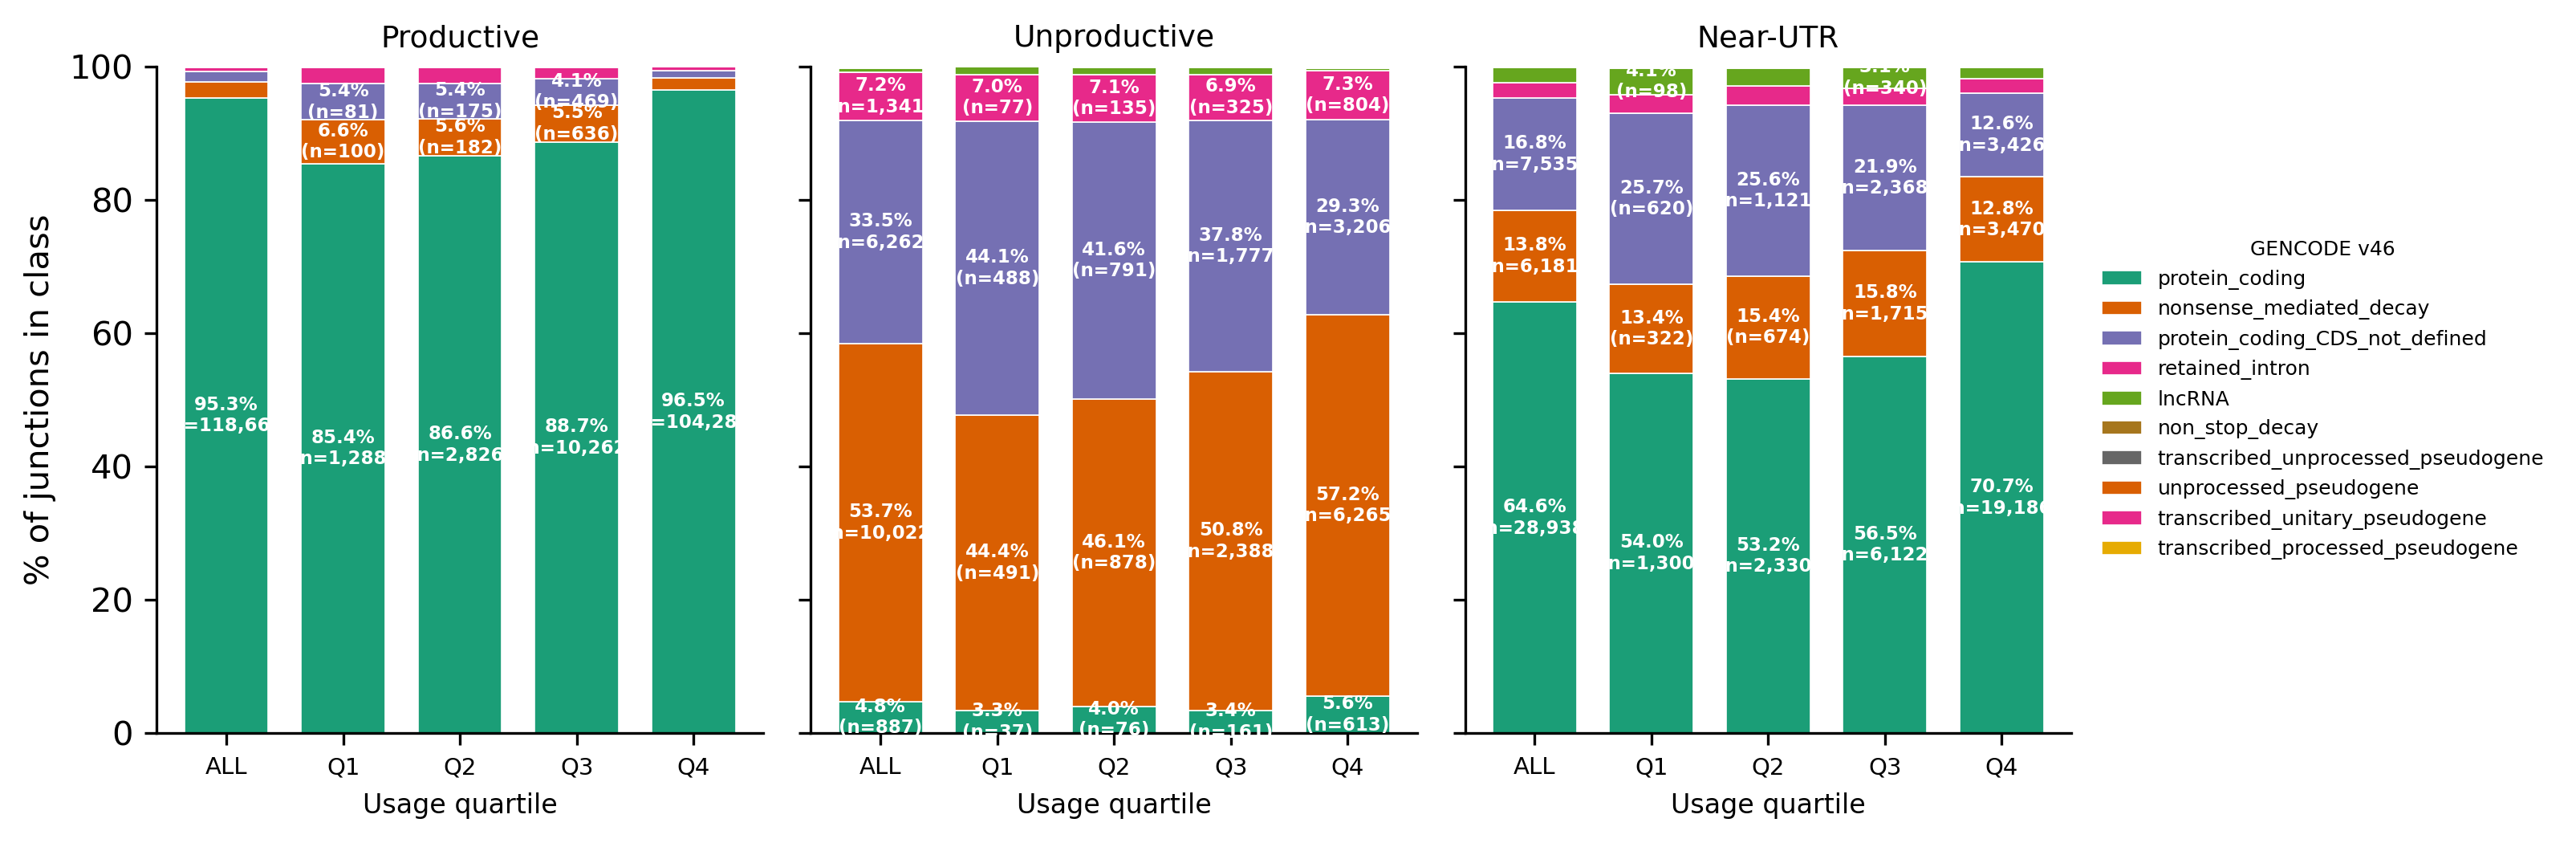

In [6]:
P.plot_fig1e(fig1e_data)
P.save_panel('fig1e', PLOTS_DIR)

top = (fig1e_data[fig1e_data.quartile == 'ALL']
       .groupby('category_label')
       .apply(lambda g: g.nlargest(3, 'n_junctions')[['gencode_annotation', 'pct_of_class']]))
print(top.round(1).to_string())

### Fig. 1g — log2 fold change, unproductive vs productive

Cumulative distribution of per-junction log2 fold change across four
perturbations that each stabilise NMD substrates. Unproductive junctions shift
right in every one; productive junctions sit on zero.

SMG6/SMG7 dKD vs control (HeLa)      Productive    n = 126,041   median log2FC = -0.023
SMG6/SMG7 dKD vs control (HeLa)      Unproductive  n =  66,179   median log2FC = +1.616
naRNA-seq vs polyA RNA-seq (LCL)     Productive    n = 162,982   median log2FC = -0.000
naRNA-seq vs polyA RNA-seq (LCL)     Unproductive  n = 110,175   median log2FC = +1.548
Cycloheximide vs DMSO (NALM6)        Productive    n = 107,820   median log2FC = +0.000
Cycloheximide vs DMSO (NALM6)        Unproductive  n =  47,249   median log2FC = +0.738
Monosome vs heavy polysome (LCL)     Productive    n =  91,647   median log2FC = +0.000
Monosome vs heavy polysome (LCL)     Unproductive  n =  29,443   median log2FC = +0.893


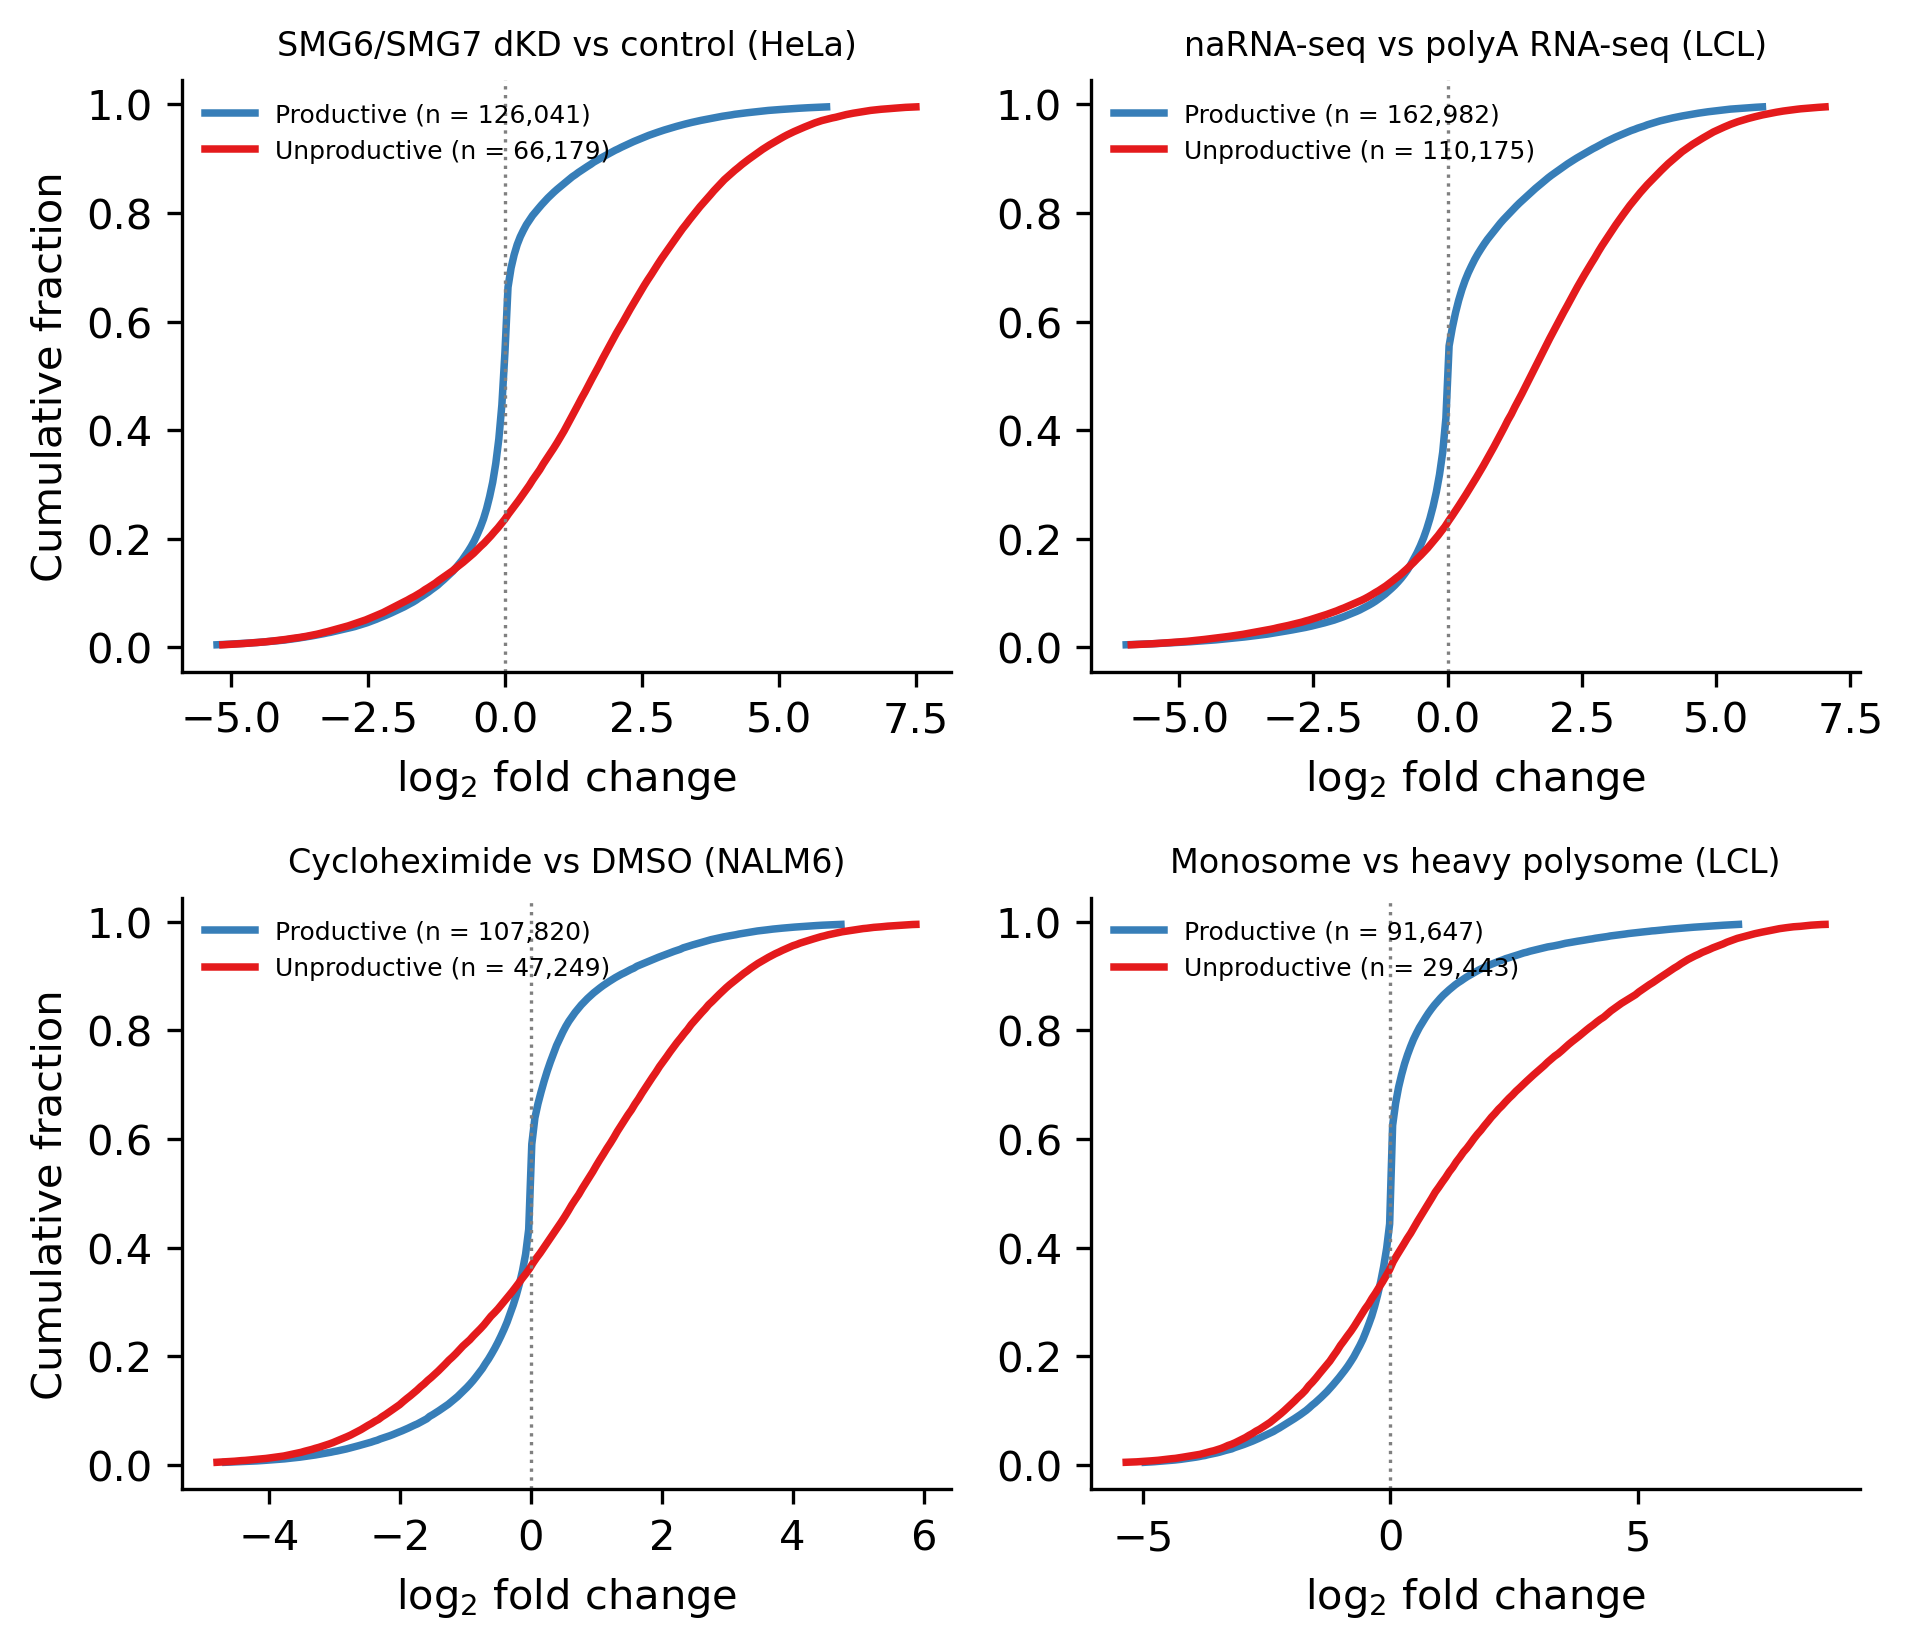

In [7]:
P.plot_fig1g(fig1g_data)
P.save_panel('fig1g', PLOTS_DIR)

for s in fig1g_data:
    if s['category'] != 'utr':
        print(f"{s['comparison_label']:<36} {s['category_label']:<13} "
              f"n = {s['n']:>7,}   median log2FC = {s['median_log2fc']:+.3f}")

### Fig. 1h — Rules predicting NMD efficiency

A premature stop codon does not always trigger degradation. Each rule splits
unproductive junctions into the group it predicts is degraded more efficiently
and the group it predicts is degraded less, and compares their naRNA-vs-polyA
log2 fold change with a one-sided Mann-Whitney U test. Coding junctions, which
carry no premature stop, are the matched negative control.

The 50-nt rule is stated as a stop codon **further** than 50 nt from the last
exon-exon junction, which is the direction the rule predicts: a stop within
50 nt of the last junction escapes degradation.

                                    rule        class   n_low  n_high  mean_low  mean_high  delta_log2fd      p_value
PTC further than 50 nt from the last EJC Unproductive  1534.0  1513.0  0.266154   0.846916      0.580762 3.612235e-13
   Number of introns upstream of the PTC Unproductive 10337.0 11288.0  1.263013   1.731663      0.468650 1.551116e-59
 Number of introns downstream of the PTC Unproductive 14128.0 10573.0  1.291348   1.770169      0.478821 2.207235e-63
PTC further than 50 nt from the last EJC   Productive     NaN     NaN       NaN        NaN           NaN          NaN
   Number of introns upstream of the PTC   Productive 16489.0 16631.0 -0.031243  -0.052416     -0.021173 7.815782e-01
 Number of introns downstream of the PTC   Productive 18723.0 17262.0 -0.023268  -0.053783     -0.030515 1.000000e+00


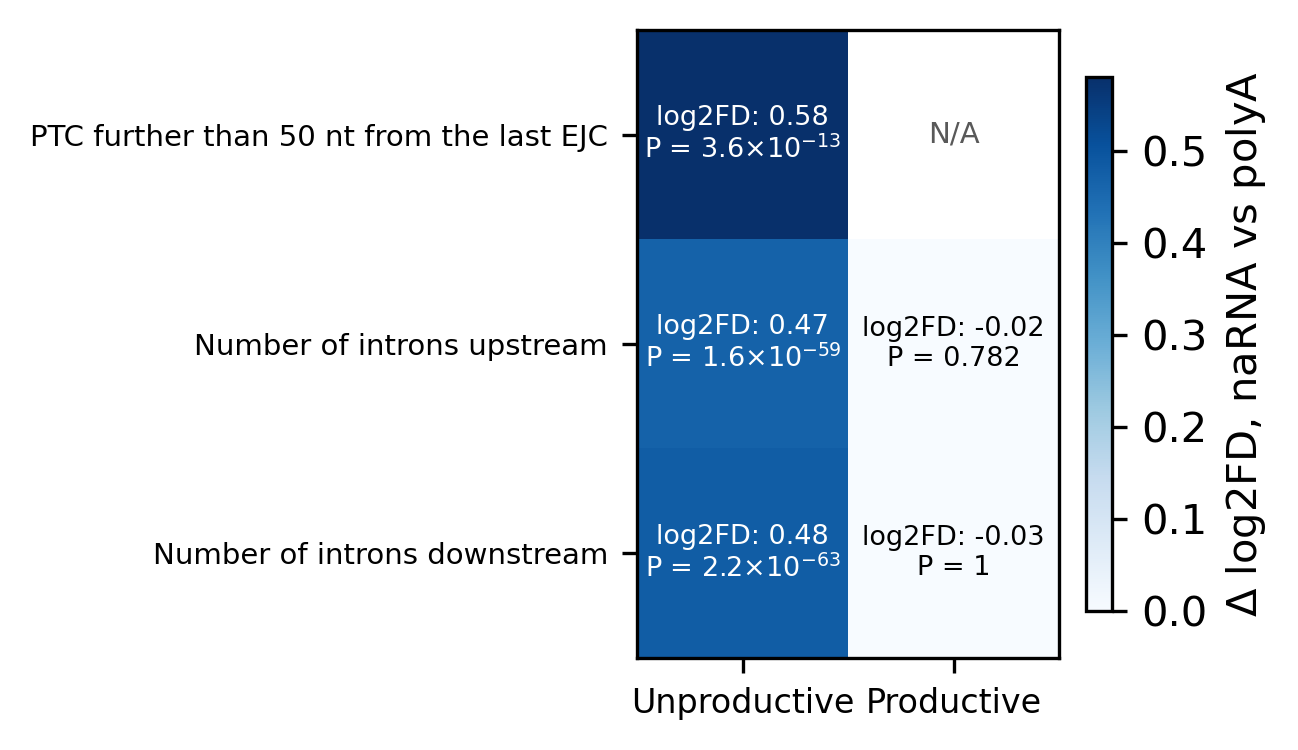

In [8]:
P.plot_fig1h(fig1h_data)
P.save_panel('fig1h', PLOTS_DIR)

cols = ['rule', 'class', 'n_low', 'n_high', 'mean_low', 'mean_high',
        'delta_log2fd', 'p_value']
print(fig1h_data[cols].to_string(index=False))

### Fig. 1i — Unproductive splicing against intron length and expression

Two properties predict how much unproductive splicing a locus carries. Long
introns carry more of it, and lowly expressed genes carry more of it. Both
panels are cumulative distributions of the unproductive fraction across the
Geuvadis panel of 373 lymphoblastoid cell lines; each line is a bin, and each
point within a line is one cluster (left) or one gene (right), averaged over
samples rather than one point per sample.

Median unproductive splicing rises from 1.5% for introns under 1 kb to 4.5%
above 50 kb, and falls from 2.7% in the lowest expression quintile to 0.2% in
the highest.

intron length     rho = +0.143   P = 4.61e-78   n = 16,841
    <1kb                     n =  5,210
    1-5kb                    n =  7,062
    5-20kb                   n =  3,307
    20-50kb                  n =    924
    >50kb                    n =    338
gene expression   rho = -0.556   P = 0   n = 6,412
    Q1 - lowly expressed     n =  1,283
    Q2                       n =  1,282
    Q3                       n =  1,282
    Q4                       n =  1,282
    Q5 - highly expressed    n =  1,283


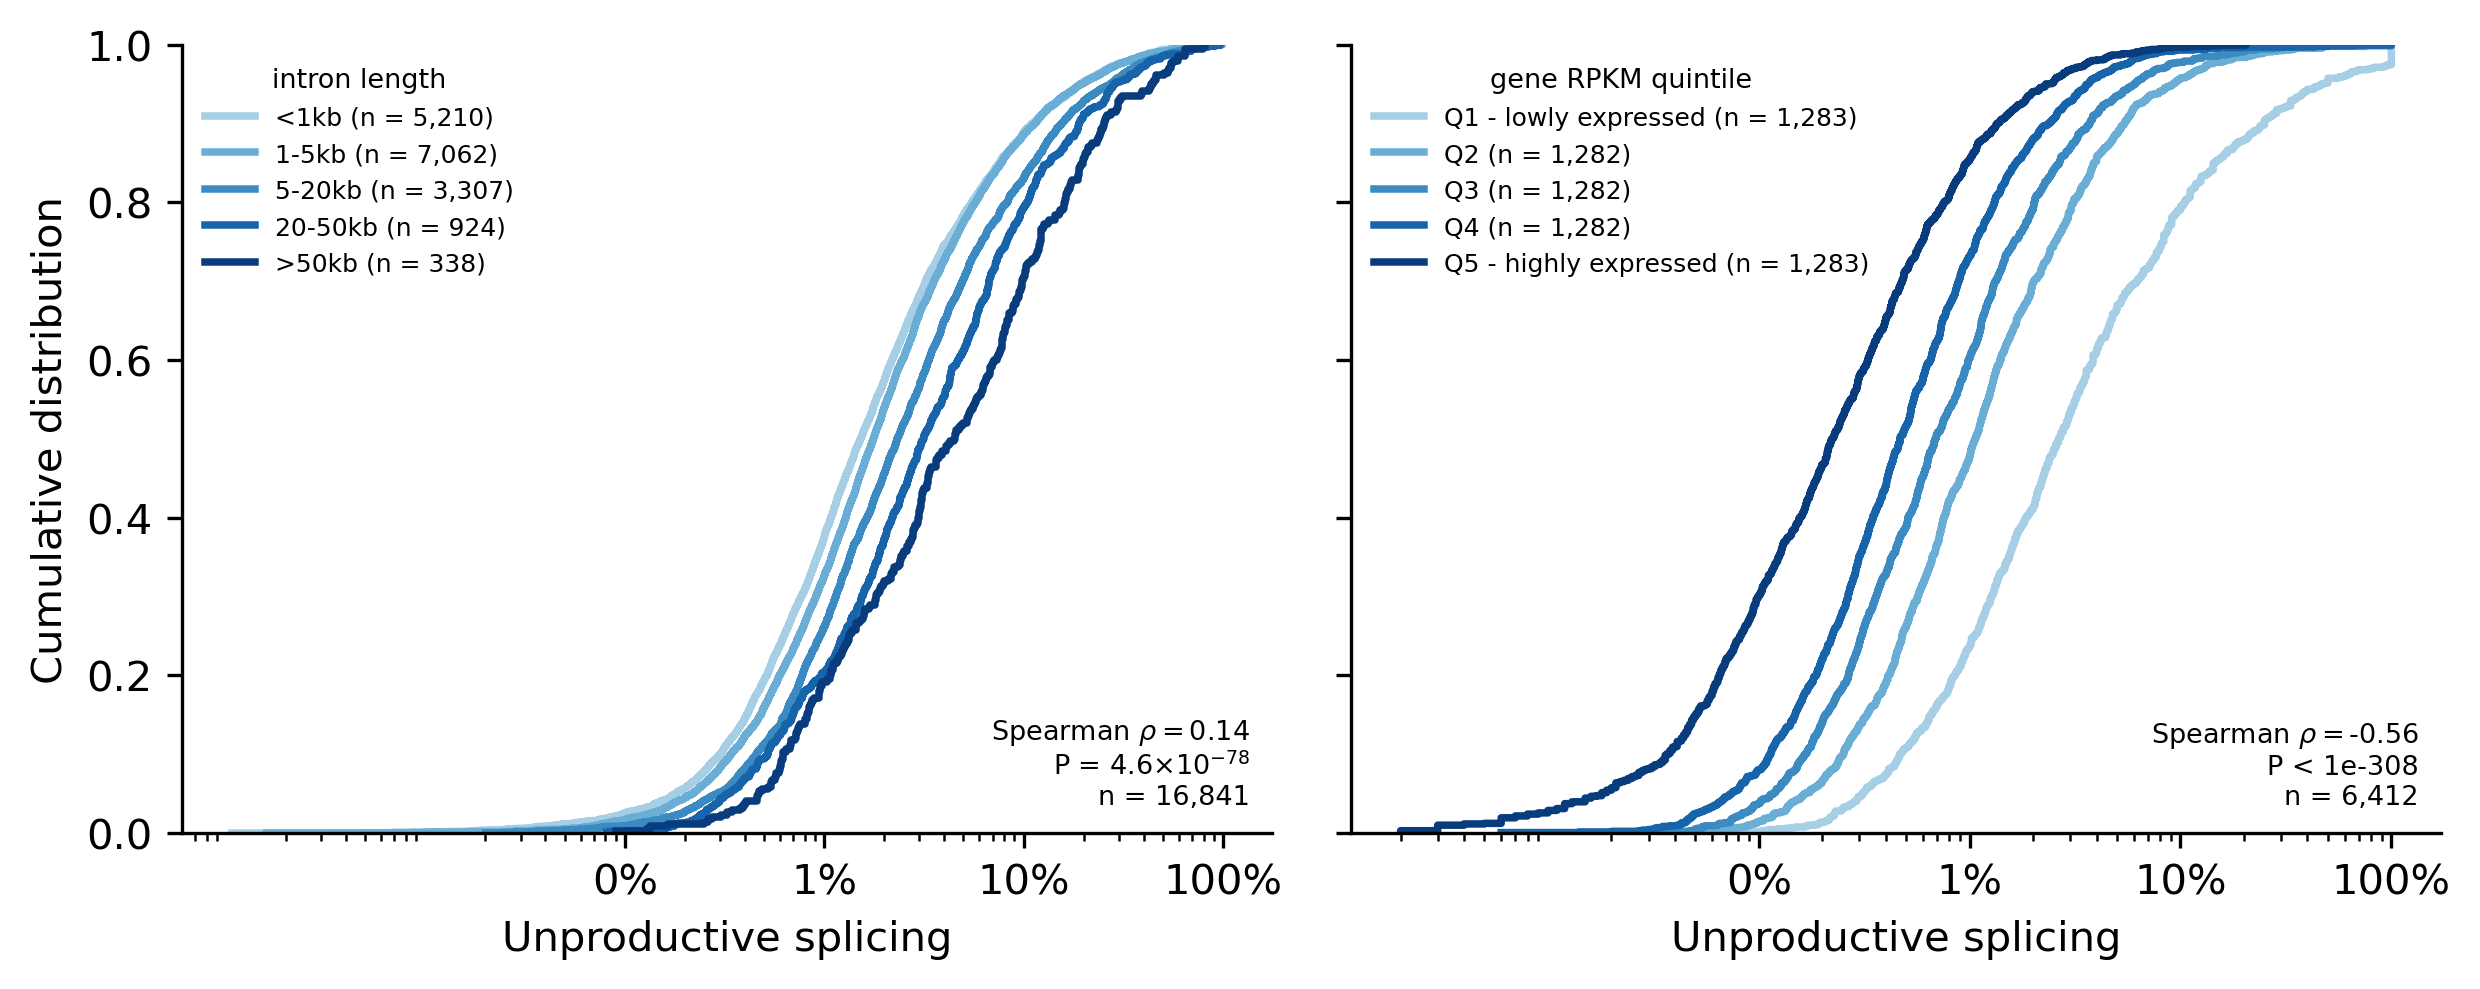

In [9]:
P.plot_fig1i(fig1i_data)
P.save_panel('fig1i', PLOTS_DIR)

for p in fig1i_data:
    print(f"{p['panel']:<17} rho = {p['rho']:+.3f}   P = {p['pvalue']:.3g}   n = {p['n']:,}")
    for s in p['series']:
        print(f"    {s['group']:<24} n = {s['n']:>6,}")